# BDI Layer - ML Classifier Training and Testing
## Train on DZ, Overtaking, Intersection datasets | Test on Fusion Dataset

This notebook trains a machine learning classifier on three scenario-based datasets and evaluates it on the Fusion dataset.

## 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Training Datasets

In [6]:
# Define paths
import os
base_path = os.path.dirname(os.path.abspath('.'))

# Load the three training datasets
print("Loading training datasets...")
dz_path = '../dataset_apres_smote_DZ.csv'
overtaking_path = '../dataset_apres_smote_overtaking.csv'
intersection_path = '../intersection.csv'
fusion_path = '../Fusion_dataset.csv'

# Load datasets
df_dz = pd.read_csv(dz_path)
df_overtaking = pd.read_csv(overtaking_path)
df_intersection = pd.read_csv(intersection_path)
df_fusion = pd.read_csv(fusion_path)

print(f"Danger Zone dataset shape: {df_dz.shape}")
print(f"Overtaking dataset shape: {df_overtaking.shape}")
print(f"Intersection dataset shape: {df_intersection.shape}")
print(f"Fusion dataset shape: {df_fusion.shape}")

print("\nDanger Zone columns:", df_dz.columns.tolist())
print("\nDanger Zone dataset sample:")
print(df_dz.head())

Loading training datasets...
Danger Zone dataset shape: (25689, 19)
Overtaking dataset shape: (33778, 17)
Intersection dataset shape: (57471, 12)
Fusion dataset shape: (103643, 26)

Danger Zone columns: ['Time', 'VehicleId', 'Pos_x', 'Pos_y', 'Speed', 'Lane', 'Acceleration', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeDistance', 'hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader', 'SafeDangerZone']

Danger Zone dataset sample:
   Time  VehicleId   Pos_x  Pos_y  Speed  Lane  Acceleration  LeaderID  \
0   0.0      10101 -100.00   -1.6   0.00    21          0.00        -1   
1   0.1      10101  -99.97   -1.6   0.30    21          2.99        -1   
2   0.2      10101  -99.91   -1.6   0.59    21          2.89        -1   
3   0.3      10101  -99.83   -1.6   0.84    21          2.57        -1   
4   0.4      10101  -99.72   -1.6   1.10    21          2.57        -1   

   LeaderSpeed  LeaderGap  Deceleration  

## 3. Combine and Prepare Training Data

In [7]:
# Add labels to each dataset
df_dz['scenario'] = 'danger_zone'
df_overtaking['scenario'] = 'overtaking'
df_intersection['scenario'] = 'intersection'

# Combine training datasets
df_train_combined = pd.concat([df_dz, df_overtaking, df_intersection], ignore_index=True)
print(f"Combined training dataset shape: {df_train_combined.shape}")
print(f"Scenario distribution:\n{df_train_combined['scenario'].value_counts()}")

# Compute deceleration from acceleration where missing
# Deceleration = -acceleration if acceleration < 0, else 0
if 'Deceleration' in df_train_combined.columns:
    mask_missing_decel = df_train_combined['Deceleration'].isnull()
    df_train_combined.loc[mask_missing_decel, 'Deceleration'] = df_train_combined.loc[mask_missing_decel, 'Acceleration'].apply(lambda a: -a if a < 0 else 0)
    print(f"Computed deceleration for {mask_missing_decel.sum()} missing values from acceleration")

# Compute RelativeSpeed from Speed and LeaderSpeed where missing
# RelativeSpeed = Speed - LeaderSpeed
if 'RelativeSpeed' in df_train_combined.columns and 'Speed' in df_train_combined.columns and 'LeaderSpeed' in df_train_combined.columns:
    mask_missing_rel_speed = df_train_combined['RelativeSpeed'].isnull()
    df_train_combined.loc[mask_missing_rel_speed, 'RelativeSpeed'] = df_train_combined.loc[mask_missing_rel_speed, 'Speed'] - df_train_combined.loc[mask_missing_rel_speed, 'LeaderSpeed']
    print(f"Computed RelativeSpeed for {mask_missing_rel_speed.sum()} missing values from Speed and LeaderSpeed")

# Compute TTC (Time To Collision) from LeaderGap and RelativeSpeed where missing
# TTC = LeaderGap / RelativeSpeed (if RelativeSpeed > 0), else 999 (no collision)
def compute_ttc(row):
    # No leader or gap <= 0 => TTC = 999
    if pd.isna(row['LeaderGap']) or pd.isna(row['RelativeSpeed']) or row['LeaderGap'] <= 0:
        return 999.0
    # RelativeSpeed <= 0 => no collision => TTC = 999
    if row['RelativeSpeed'] <= 0:
        return 999.0
    # Otherwise: TTC = gap / relative speed
    return row['LeaderGap'] / row['RelativeSpeed']

if 'TTC' in df_train_combined.columns and 'LeaderGap' in df_train_combined.columns and 'RelativeSpeed' in df_train_combined.columns:
    mask_missing_ttc = df_train_combined['TTC'].isnull()
    df_train_combined.loc[mask_missing_ttc, 'TTC'] = df_train_combined.loc[mask_missing_ttc].apply(compute_ttc, axis=1)
    print(f"Computed TTC for {mask_missing_ttc.sum()} missing values from LeaderGap and RelativeSpeed")

# Handle remaining missing values with scenario-specific imputation
print(f"\nMissing values in combined training data before imputation:")
missing = df_train_combined.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Strategy: Scenario-based imputation (better than global mean)
# This fills missing values using the scenario-specific mean, preserving scenario characteristics
numeric_cols_to_impute = df_train_combined.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_to_impute = [col for col in numeric_cols_to_impute if col not in ['Time', 'VehicleId', 'Pos_x', 'Pos_y']]

for col in numeric_cols_to_impute:
    if df_train_combined[col].isnull().sum() > 0:
        # Fill with scenario-specific mean (preserves scenario characteristics)
        df_train_combined[col] = df_train_combined.groupby('scenario')[col].transform(
            lambda x: x.fillna(x.mean())
        )
        # For any remaining NaN (entire group missing), fill with global mean
        df_train_combined[col] = df_train_combined[col].fillna(df_train_combined[col].mean())

# Handle boolean columns: fill with False (0) instead of mean
boolean_cols = ['hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader', 'lane_opposite_change']
for col in boolean_cols:
    if col in df_train_combined.columns and df_train_combined[col].isnull().sum() > 0:
        df_train_combined[col] = df_train_combined[col].fillna(0)  # False = no event occurred
        print(f"Filled {df_train_combined[col].isnull().sum()} missing boolean values in '{col}' with 0 (False)")

# Use sentinel value (999) for scenario-specific features when missing
scenario_cols = ['Type', 'Slope', 'SafeUnsafeCrossing', 'SafeUnsafeOvertaking', 'SafeDangerZone']
for col in scenario_cols:
    if col in df_train_combined.columns and df_train_combined[col].isnull().sum() > 0:
        df_train_combined[col] = df_train_combined[col].fillna(999)
        print(f"Filled {df_train_combined[col].isnull().sum()} missing values in '{col}' with sentinel value 999")

# Check final missing values
print(f"\nFinal missing values after smart imputation:")
missing_final = df_train_combined.isnull().sum()
print(missing_final[missing_final > 0] if missing_final.sum() > 0 else "No missing values - data ready!")
print(f"\nFinal training dataset shape: {df_train_combined.shape}")

Combined training dataset shape: (116938, 25)
Scenario distribution:
scenario
intersection    57471
overtaking      33778
danger_zone     25689
Name: count, dtype: int64
Computed deceleration for 57471 missing values from acceleration
Computed RelativeSpeed for 57471 missing values from Speed and LeaderSpeed
Computed TTC for 57471 missing values from LeaderGap and RelativeSpeed

Missing values in combined training data before imputation:
SafeDistance                     57471
hard_brake                       91249
danger_accel_toward_leader       91249
leader_stopped                   91249
no_reaction_to_stopped_leader    91249
SafeDangerZone                   91249
LanePrev                         83160
lane_opposite_change             83160
SafeUnsafeOvertaking             83160
Type                             59467
Slope                            59467
dtype: int64
Filled 0 missing boolean values in 'hard_brake' with 0 (False)
Filled 0 missing boolean values in 'danger_accel_towa

### Feature Engineering and Selection

In [8]:
# Select features for the model (exclude Time, VehicleId, and target columns)
exclude_cols = ['Time', 'VehicleId', 'scenario', 'Pos_x', 'Pos_y']

# Identify numeric features
feature_cols = [col for col in df_train_combined.columns 
                 if col not in exclude_cols and df_train_combined[col].dtype in ['int64', 'float64']]

# Convert boolean columns to numeric if present
boolean_cols = [col for col in df_train_combined.columns 
                if df_train_combined[col].dtype == 'bool' or col in ['hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader']]

feature_cols = [col for col in feature_cols if col not in boolean_cols] + boolean_cols

print(f"Selected features ({len(feature_cols)}):") 
print(feature_cols)

# Prepare features and target
X_train = df_train_combined[feature_cols].copy()
y_train = df_train_combined['scenario'].copy()

# Handle NaN in boolean columns first, then convert to numeric
for col in boolean_cols:
    if col in X_train.columns:
        # Fill NaN with False (0) for boolean columns
        X_train[col] = X_train[col].fillna(False)
        X_train[col] = X_train[col].astype(int)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"\nFeature data types:\n{X_train.dtypes}")

Selected features (18):
['Speed', 'Lane', 'Acceleration', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeDistance', 'SafeDangerZone', 'LanePrev', 'SafeUnsafeOvertaking', 'Slope', 'hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader']

Training features shape: (116938, 18)
Training target shape: (116938,)

Feature data types:
Speed                            float64
Lane                             float64
Acceleration                     float64
LeaderID                         float64
LeaderSpeed                      float64
LeaderGap                        float64
Deceleration                     float64
RelativeSpeed                    float64
TTC                              float64
SafeDistance                     float64
SafeDangerZone                   float64
LanePrev                         float64
SafeUnsafeOvertaking             float64
Slope                            float64
hard_brake           

## 4. Split Data into Training and Validation Sets

In [9]:
# Split into training and validation sets (80-20 split)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_train_split.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"\nTraining set scenario distribution:")
print(y_train_split.value_counts())
print(f"\nValidation set scenario distribution:")
print(y_val.value_counts())

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

print("\nFeatures standardized using StandardScaler")

Training set size: 93550
Validation set size: 23388

Training set scenario distribution:
scenario
intersection    45977
overtaking      27022
danger_zone     20551
Name: count, dtype: int64

Validation set scenario distribution:
scenario
intersection    11494
overtaking       6756
danger_zone      5138
Name: count, dtype: int64

Features standardized using StandardScaler


## 5. Train ML Classifier

In [10]:
print("Training multiple classifiers...\n")

# Initialize classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

trained_models = {}
training_scores = {}

# Train each classifier
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train_split)
    trained_models[name] = clf
    
    # Get training score
    train_score = clf.score(X_train_scaled, y_train_split)
    training_scores[name] = train_score
    print(f"{name} - Training Accuracy: {train_score:.4f}")

print("\nAll models trained successfully!")

# Select best model based on training accuracy
best_model_name = max(training_scores, key=training_scores.get)
best_model = trained_models[best_model_name]
print(f"\nBest model: {best_model_name} (Training Accuracy: {training_scores[best_model_name]:.4f})")

Training multiple classifiers...

Training Random Forest...
Random Forest - Training Accuracy: 1.0000
Training Gradient Boosting...
Gradient Boosting - Training Accuracy: 1.0000
Training SVM...
SVM - Training Accuracy: 1.0000

All models trained successfully!

Best model: Random Forest (Training Accuracy: 1.0000)


## 6. Evaluate Classifier on Validation Set

In [11]:
# Make predictions on validation set
y_val_pred = best_model.predict(X_val_scaled)
y_val_pred_proba = best_model.predict_proba(X_val_scaled)

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print(f"Validation Set Metrics ({best_model_name}):")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  F1-Score:  {val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Confusion Matrix
cm_val = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix (Validation):")
print(cm_val)

Validation Set Metrics (Random Forest):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

 danger_zone       1.00      1.00      1.00      5138
intersection       1.00      1.00      1.00     11494
  overtaking       1.00      1.00      1.00      6756

    accuracy                           1.00     23388
   macro avg       1.00      1.00      1.00     23388
weighted avg       1.00      1.00      1.00     23388


Confusion Matrix (Validation):
[[ 5138     0     0]
 [    0 11494     0]
 [    0     0  6756]]


### Validation Set - Confusion Matrix Visualization

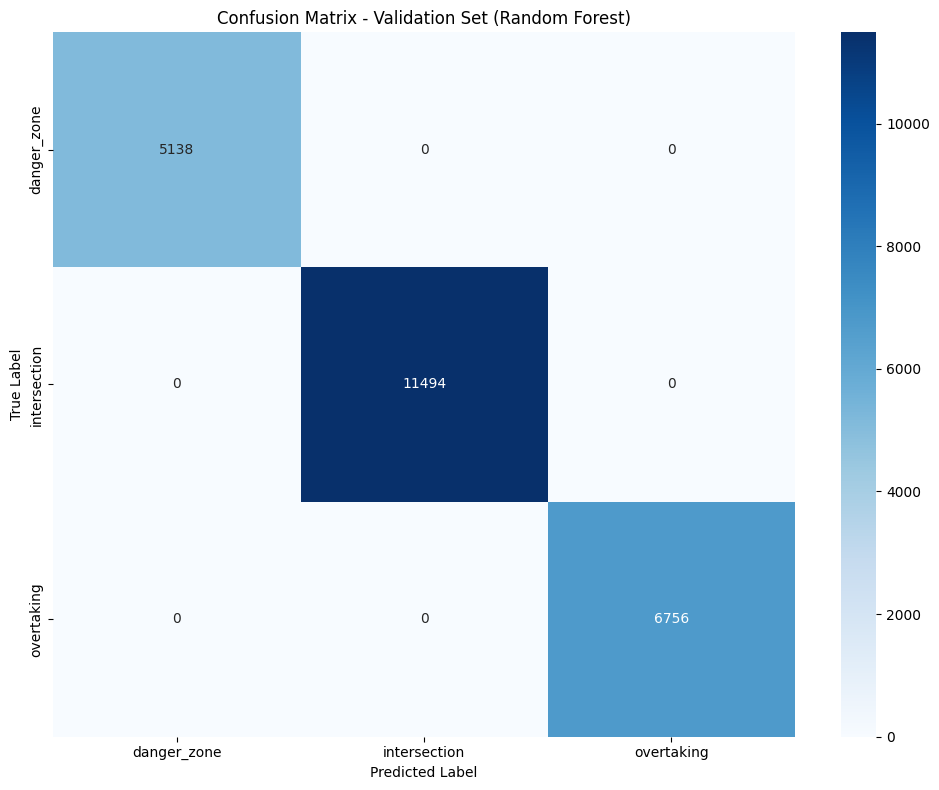

Validation confusion matrix plotted


In [12]:
# Visualize confusion matrix for validation set
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - Validation Set ({best_model_name})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Validation confusion matrix plotted")

## 7. Load and Prepare Fusion Dataset

In [13]:
# Prepare Fusion dataset with same features
print("Preparing Fusion dataset...")
print(f"Fusion dataset shape: {df_fusion.shape}")
print(f"Fusion dataset columns: {df_fusion.columns.tolist()}")

# Handle missing values in Fusion dataset
df_fusion_clean = df_fusion.fillna(df_fusion.mean(numeric_only=True))

# Add missing columns to Fusion dataset using mean values from training data
for col in feature_cols:
    if col not in df_fusion_clean.columns:
        if col in df_train_combined.columns:
            # Use mean value from training data for missing columns
            mean_val = df_train_combined[col].mean()
            df_fusion_clean[col] = mean_val
            print(f"Added missing column '{col}' with mean value: {mean_val:.2f}")
        
# Now extract features using original feature_cols
X_fusion = df_fusion_clean[feature_cols].copy()

# Convert boolean columns to numeric
for col in boolean_cols:
    if col in X_fusion.columns:
        # Fill NaN with False (0) for boolean columns
        X_fusion[col] = X_fusion[col].fillna(False)
        X_fusion[col] = X_fusion[col].astype(int)

# Standardize using same scaler
X_fusion_scaled = scaler.transform(X_fusion)

print(f"\nFusion features prepared: {X_fusion_scaled.shape}")
print("Fusion dataset ready for testing!")

Preparing Fusion dataset...
Fusion dataset shape: (103643, 26)
Fusion dataset columns: ['Time', 'VehicleId', 'Pos_x', 'Pos_y', 'Speed', 'Lane', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Acceleration', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeUnsafeCrossing', 'Scenario', 'AccidentTypes', 'SafeDistance', 'LanePrev', 'lane_opposite_change', 'SafeUnsafeOvertaking', 'hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader', 'SafeDangerZone', 'IsAccidentCase']
Added missing column 'Slope' with mean value: 0.00

Fusion features prepared: (103643, 18)
Fusion dataset ready for testing!


## 8. Test Classifier on Fusion Dataset